In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import json
from datetime import datetime
plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
CONFIG = {
    'data_dir':'C:\Python\ML Intro\Projects\Medical Image Classification\data\chest_xray',
    'img_size':(150,150), # Start with smaller size for baseline
    'batch_size':32,
    'epochs':25,
    'learning_rate': 0.001,
    'model_name': 'baseline_cnn',
    'seed': 42
}
Path('C:\Python\ML Intro\Projects\Medical Image Classification\models').mkdir(exist_ok=True)
Path('C:/Python/ML Intro/Projects/Medical Image Classification/results/plots').mkdir(parents=True,exist_ok=True)
Path('C:\Python/ML Intro/Projects/Medical Image Classification/results/metrics').mkdir(parents=True,exist_ok=True)

In [5]:
with open('C:\Python/ML Intro/Projects/Medical Image Classification/results/metrics/baseline_config.json','w') as f:
    json.dump(CONFIG,f,indent=4)

print("CONFIGURATION")
for key,value in CONFIG.items():
    print(f"{key}:{value}")

CONFIGURATION
data_dir:C:\Python\ML Intro\Projects\Medical Image Classification\data\chest_xray
img_size:(150, 150)
batch_size:32
epochs:25
learning_rate:0.001
model_name:baseline_cnn
seed:42


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # Normalize pixel values to [0,1]
    rotation_range=20,               # Randomly rotate images by 20 degrees
    width_shift_range=0.2,           # Randomly shift width by 20%
    height_shift_range=0.2,          # Randomly shift height by 20%
    shear_range=0.2,                 # Shear transformation
    zoom_range=0.2,                  # Random zoom
    horizontal_flip=True,            # Randomly flip images horizontally
    fill_mode='nearest'              # Fill pixels after transformations
)
# Validation and test sets - only rescaling (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)
print(" Data augmentation setup complete")
print("\n Augmentation parameters:")
print("   - Rotation: ±20°")
print("   - Shift: ±20%")
print("   - Zoom: ±20%")
print("   - Horizontal flip: Yes")

 Data augmentation setup complete

 Augmentation parameters:
   - Rotation: ±20°
   - Shift: ±20%
   - Zoom: ±20%
   - Horizontal flip: Yes


In [8]:
# Define paths
train_dir = Path(CONFIG['data_dir']) / 'train'
val_dir = Path(CONFIG['data_dir']) / 'val'
test_dir = Path(CONFIG['data_dir']) / 'test'
# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',              # Binary classification (0: NORMAL, 1: PNEUMONIA)
    shuffle=True,
    seed=CONFIG['seed']
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    shuffle=False
)
print("\nData Generators Created:")
print(f"   Train samples: {train_generator.samples}")
print(f"   Validation samples: {val_generator.samples}")
print(f"   Test samples: {test_generator.samples}")
print(f"\n   Class indices: {train_generator.class_indices}")
print(f"   Steps per epoch (train): {len(train_generator)}")


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Data Generators Created:
   Train samples: 5216
   Validation samples: 16
   Test samples: 624

   Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
   Steps per epoch (train): 163


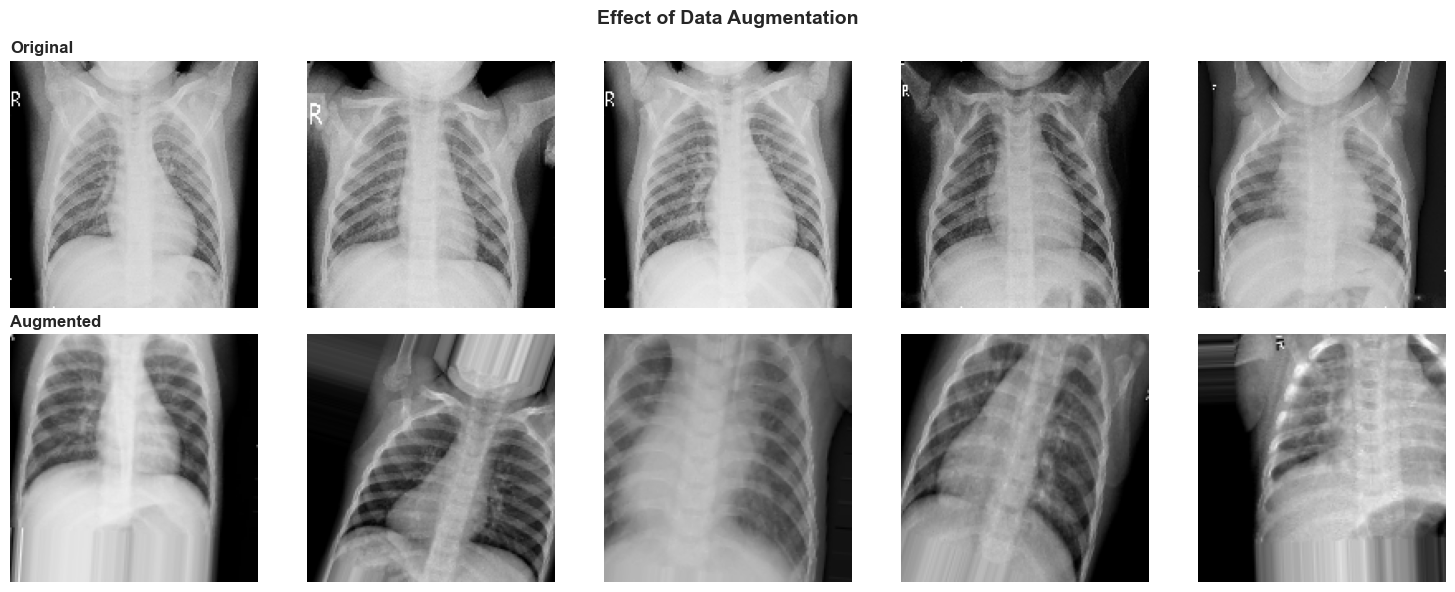

In [ ]:
# Visualize augmentation effects
def show_augmented_images(generator, num_images=5):
    """Display original and augmented versions of images"""
    
    # Get a batch
    batch_images, batch_labels = next(generator)
    
    fig, axes = plt.subplots(2, num_images, figsize=(15, 6))
    
    for i in range(num_images):
        # Original (from validation set - no augmentation)
        val_batch, _ = next(val_generator)
        axes[0, i].imshow(val_batch[i])
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontweight='bold', loc='left')
        
        # Augmented
        axes[1, i].imshow(batch_images[i])
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Augmented', fontweight='bold', loc='left')
    
    plt.suptitle('Effect of Data Augmentation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('C:\Python/ML Intro/Projects/Medical Image Classification/results/plots/augmentation_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

show_augmented_images(train_generator)

In [10]:
def create_baseline_cnn(input_shape=(150, 150, 3)):
    """
    Build a simple CNN from scratch
    Architecture:
    - 3 Convolutional blocks (Conv2D + MaxPooling)
    - Flatten layer
    - 2 Dense layers with dropout
    - Binary output
    """
    
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', name='conv3'),
        layers.MaxPooling2D((2, 2), name='pool3'),
        
        # Block 4 (deeper)
        layers.Conv2D(128, (3, 3), activation='relu', name='conv4'),
        layers.MaxPooling2D((2, 2), name='pool4'),
        
        # Flatten and Dense layers
        layers.Flatten(name='flatten'),
        layers.Dropout(0.5, name='dropout1'),
        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout2'),
        layers.Dense(1, activation='sigmoid', name='output')  # Binary classification
    ], name='baseline_cnn')
    
    return model

# Create model
model = create_baseline_cnn(input_shape=(*CONFIG['img_size'], 3))

# Display architecture
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")



Model: "baseline_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 148, 148, 32)      896       
                                                                 
 pool1 (MaxPooling2D)        (None, 74, 74, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 72, 72, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 36, 36, 64)        0         
                                                                 
 conv3 (Conv2D)              (None, 34, 34, 128)       73856     
                                                                 
 pool3 (MaxPooling2D)        (None, 17, 17, 128)       0         
                                                                 
 conv4 (Conv2D)              (None, 15, 15, 128)    

In [11]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("Model compiled successfully!")
print("\nOptimizer: Adam")
print(f"Learning rate: {CONFIG['learning_rate']}")
print("Loss: Binary Crossentropy")
print("Metrics: Accuracy, Precision, Recall, AUC")

Model compiled successfully!

Optimizer: Adam
Learning rate: 0.001
Loss: Binary Crossentropy
Metrics: Accuracy, Precision, Recall, AUC


In [12]:
# Define callbacks
callbacks = [
    # Stop training if validation loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,              # Reduce LR by half
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Save best model
    ModelCheckpoint(
        filepath='C:\Python/ML Intro/Projects/Medical Image Classification/models/baseline_cnn_best.h5',
        monitor='val_auc',       # Monitor AUC (better for imbalanced data)
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
print("   1. Early Stopping (patience=5)")
print("   2. Reduce LR on Plateau (factor=0.5, patience=3)")
print("   3. Model Checkpoint (saving best model based on val_auc)")

Callbacks configured:
   1. Early Stopping (patience=5)
   2. Reduce LR on Plateau (factor=0.5, patience=3)
   3. Model Checkpoint (saving best model based on val_auc)


In [13]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(" Class Weights (to handle imbalance):")
print(f"   Class 0 (NORMAL): {class_weight_dict[0]:.2f}")
print(f"   Class 1 (PNEUMONIA): {class_weight_dict[1]:.2f}")
print("\n Higher weight for minority class helps model focus on it")

 Class Weights (to handle imbalance):
   Class 0 (NORMAL): 1.94
   Class 1 (PNEUMONIA): 0.67

 Higher weight for minority class helps model focus on it


In [14]:
print(" Starting training...")
print("=" * 60)

# Start training
history = model.fit(
    train_generator,
    epochs=CONFIG['epochs'],
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('C:\Python/ML Intro/Projects/Medical Image Classification/results/metrics/baseline_training_history.csv', index=False)
print("Training history saved to results/metrics/")

 Starting training...
Epoch 1/25


163/163 [==============================] - ETA: 0s - loss: 0.6616 - accuracy: 0.5805 - precision: 0.8153 - recall: 0.5628 - auc: 0.6435
Epoch 1: val_auc improved from -inf to 0.81250, saving model to C:\Python/ML Intro/Projects/Medical Image Classification/models\baseline_cnn_best.h5
163/163 [==============================] - 132s 799ms/step - loss: 0.6616 - accuracy: 0.5805 - precision: 0.8153 - recall: 0.5628 - auc: 0.6435 - val_loss: 0.5965 - val_accuracy: 0.6875 - val_precision: 0.6364 - val_recall: 0.8750 - val_auc: 0.8125 - lr: 0.0010
Epoch 2/25


c:\Users\Adhiraj\miniconda3\envs\dl\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


163/163 [==============================] - ETA: 0s - loss: 0.5631 - accuracy: 0.6980 - precision: 0.9027 - recall: 0.6653 - auc: 0.7831
Epoch 2: val_auc improved from 0.81250 to 0.87500, saving model to C:\Python/ML Intro/Projects/Medical Image Classification/models\baseline_cnn_best.h5
163/163 [==============================] - 98s 601ms/step - loss: 0.5631 - accuracy: 0.6980 - precision: 0.9027 - recall: 0.6653 - auc: 0.7831 - val_loss: 0.5279 - val_accuracy: 0.6250 - val_precision: 0.7500 - val_recall: 0.3750 - val_auc: 0.8750 - lr: 0.0010
Epoch 3/25
163/163 [==============================] - ETA: 0s - loss: 0.4618 - accuracy: 0.7605 - precision: 0.9374 - recall: 0.7262 - auc: 0.8649
Epoch 3: val_auc improved from 0.87500 to 0.90625, saving model to C:\Python/ML Intro/Projects/Medical Image Classification/models\baseline_cnn_best.h5
163/163 [==============================] - 130s 795ms/step - loss: 0.4618 - accuracy: 0.7605 - precision: 0.9374 - recall: 0.7262 - auc: 0.8649 - val_lo

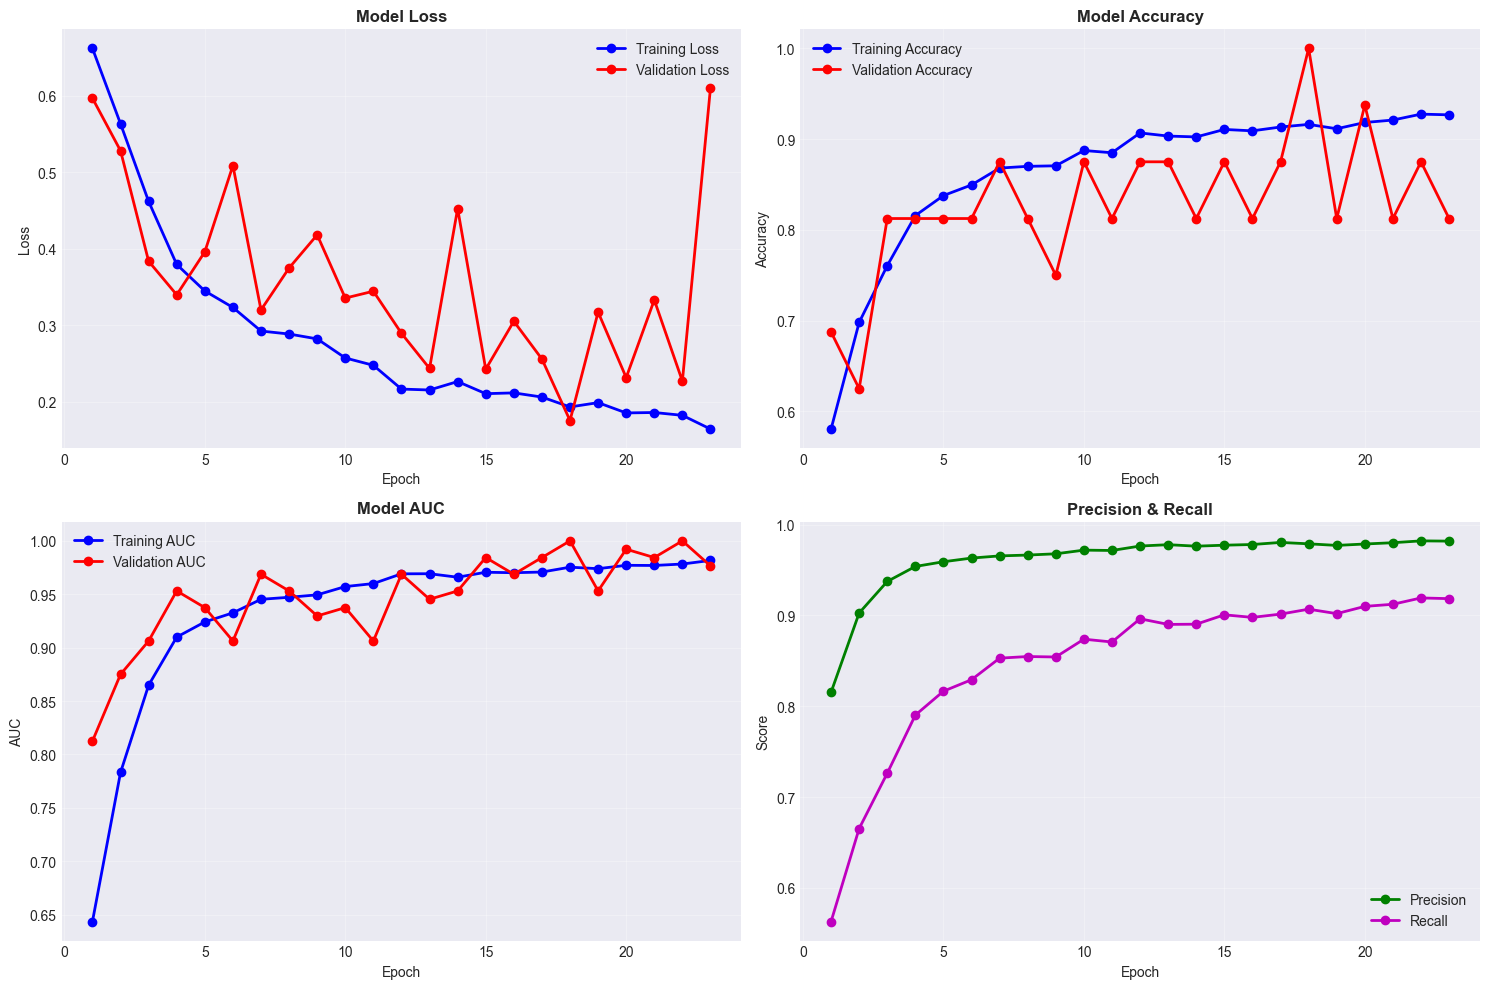


 Best Epoch: 18
   Val Accuracy: 1.0000
   Val AUC: 1.0000
   Val Loss: 0.1758


In [16]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Get history
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, hist['loss'], 'b-o', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, hist['val_loss'], 'r-o', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Model Loss', fontweight='bold', fontsize=12)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(epochs, hist['accuracy'], 'b-o', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, hist['val_accuracy'], 'r-o', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title('Model Accuracy', fontweight='bold', fontsize=12)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # AUC
    axes[1, 0].plot(epochs, hist['auc'], 'b-o', label='Training AUC', linewidth=2)
    axes[1, 0].plot(epochs, hist['val_auc'], 'r-o', label='Validation AUC', linewidth=2)
    axes[1, 0].set_title('Model AUC', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Precision & Recall
    axes[1, 1].plot(epochs, hist['precision'], 'g-o', label='Precision', linewidth=2)
    axes[1, 1].plot(epochs, hist['recall'], 'm-o', label='Recall', linewidth=2)
    axes[1, 1].set_title('Precision & Recall', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('C:\Python/ML Intro/Projects/Medical Image Classification/results/plots/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print best epoch
    best_epoch = np.argmax(hist['val_auc']) + 1
    print(f"\n Best Epoch: {best_epoch}")
    print(f"   Val Accuracy: {hist['val_accuracy'][best_epoch-1]:.4f}")
    print(f"   Val AUC: {hist['val_auc'][best_epoch-1]:.4f}")
    print(f"   Val Loss: {hist['val_loss'][best_epoch-1]:.4f}")

plot_training_history(history)

In [19]:
print("Evaluating on test set...")

# Load best model
best_model = keras.models.load_model('C:\Python/ML Intro/Projects/Medical Image Classification/models/baseline_cnn_best.h5')

# Evaluate
test_results = best_model.evaluate(test_generator, verbose=1)

# Print results
print("\n" + "=" * 60)
print(" TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss:      {test_results[0]:.4f}")
print(f"Test Accuracy:  {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall:    {test_results[3]:.4f}")
print(f"Test AUC:       {test_results[4]:.4f}")
print("=" * 60)

# Save test results
test_metrics = {
    'test_loss': float(test_results[0]),
    'test_accuracy': float(test_results[1]),
    'test_precision': float(test_results[2]),
    'test_recall': float(test_results[3]),
    'test_auc': float(test_results[4])
}

with open('C:\Python/ML Intro/Projects/Medical Image Classification/results/metrics/baseline_test_results.json', 'w') as f:
    json.dump(test_metrics, f, indent=4)

Evaluating on test set...
20/20 [==============================] - 4s 180ms/step - loss: 0.2805 - accuracy: 0.8974 - precision: 0.9503 - recall: 0.8821 - auc: 0.9529

 TEST SET RESULTS
Test Loss:      0.2805
Test Accuracy:  0.8974 (89.74%)
Test Precision: 0.9503
Test Recall:    0.8821
Test AUC:       0.9529


 Generating predictions...
20/20 [==============================] - 5s 206ms/step

 Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.8244    0.9231    0.8710       234
   PNEUMONIA     0.9503    0.8821    0.9149       390

    accuracy                         0.8974       624
   macro avg     0.8874    0.9026    0.8929       624
weighted avg     0.9031    0.8974    0.8984       624



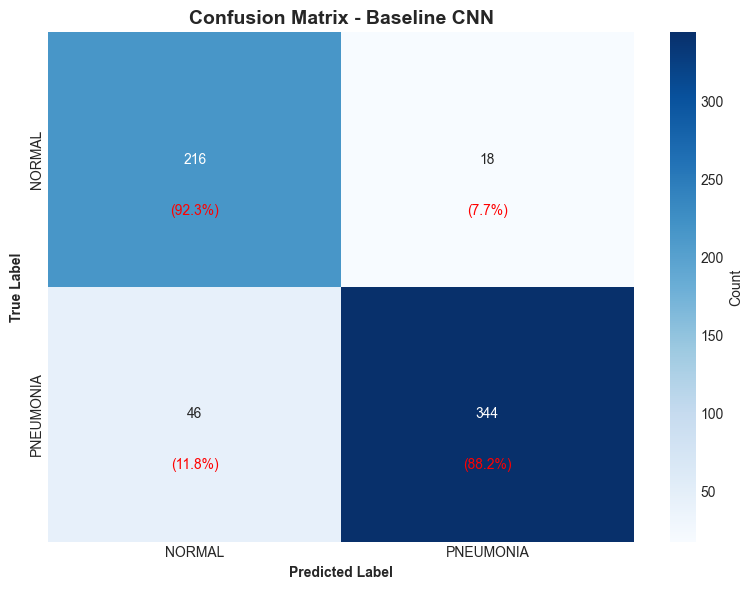


Confusion Matrix:
   True Negatives:  216 (correctly identified NORMAL)
   False Positives: 18 (NORMAL predicted as PNEUMONIA)
   False Negatives: 46 (PNEUMONIA predicted as NORMAL) 
   True Positives:  344 (correctly identified PNEUMONIA)


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
print(" Generating predictions...")
test_generator.reset()  # Reset generator
predictions = best_model.predict(test_generator, verbose=1)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Classification report
print("\n Classification Report:")
print(classification_report(y_true, y_pred, 
                          target_names=['NORMAL', 'PNEUMONIA'],
                          digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Baseline CNN', fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('C:\Python/ML Intro/Projects/Medical Image Classification/results/plots/baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix:")
print(f"   True Negatives:  {cm[0,0]} (correctly identified NORMAL)")
print(f"   False Positives: {cm[0,1]} (NORMAL predicted as PNEUMONIA)")
print(f"   False Negatives: {cm[1,0]} (PNEUMONIA predicted as NORMAL) ")
print(f"   True Positives:  {cm[1,1]} (correctly identified PNEUMONIA)")

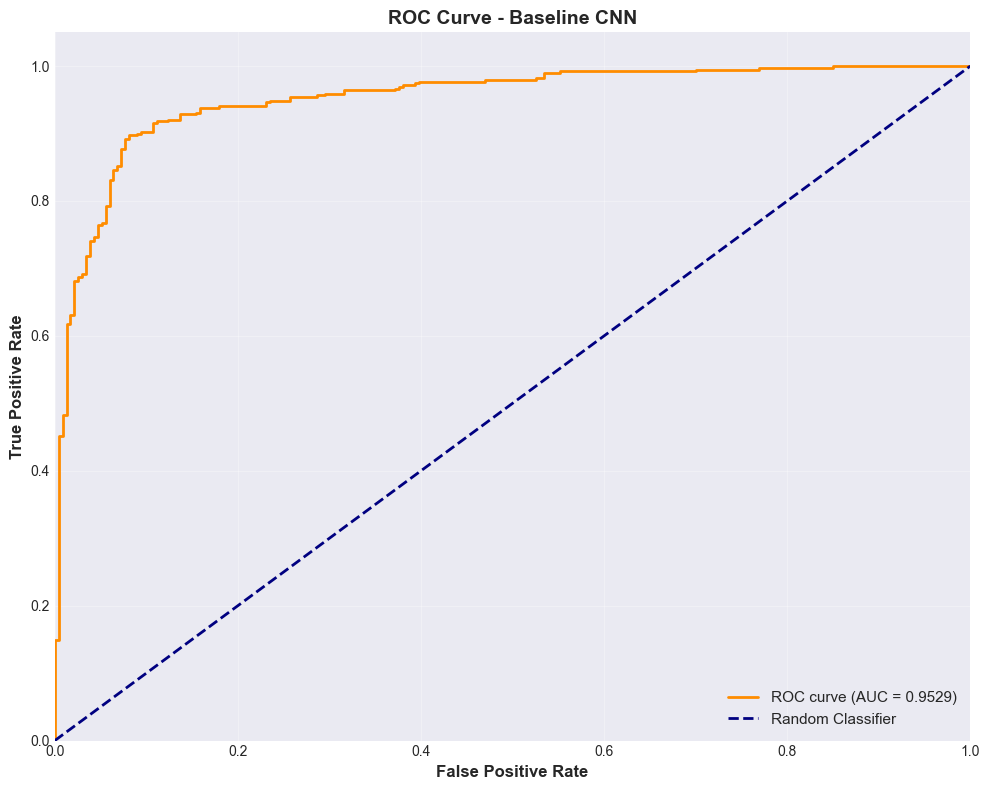

AUC Score: 0.9529


In [22]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, predictions)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curve - Baseline CNN', fontweight='bold', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:\Python/ML Intro/Projects/Medical Image Classification/results/plots/baseline_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [23]:
print("=" * 70)
print(" WEEK 2 - BASELINE MODEL SUMMARY")
print("=" * 70)

print(f"\n  Model Architecture:")
print(f"   - Type: Custom CNN (4 conv blocks)")
print(f"   - Parameters: {model.count_params():,}")
print(f"   - Input size: {CONFIG['img_size']}")

print(f"\n Training:")
print(f"   - Epochs trained: {len(history.history['loss'])}")
print(f"   - Batch size: {CONFIG['batch_size']}")
print(f"   - Data augmentation: Yes")
print(f"   - Class weighting: Yes")

print(f"\n Test Performance:")
print(f"   - Accuracy:  {test_metrics['test_accuracy']*100:.2f}%")
print(f"   - Precision: {test_metrics['test_precision']:.4f}")
print(f"   - Recall:    {test_metrics['test_recall']:.4f}")
print(f"   - AUC:       {test_metrics['test_auc']:.4f}")

print(f"\n Saved Files:")
print(f"   ✓ Model: models/baseline_cnn_best.h5")
print(f"   ✓ Training history: results/metrics/baseline_training_history.csv")
print(f"   ✓ Test results: results/metrics/baseline_test_results.json")
print(f"   ✓ Plots: results/plots/")

print(f"\n Next Steps (Week 3):")
print(f"   1. Implement transfer learning (EfficientNet/ResNet)")
print(f"   2. Use larger image size (224x224)")
print(f"   3. Fine-tune pre-trained model")
print(f"   4. Compare with baseline")
print(f"   5. Target: >90% accuracy, >0.95 AUC")

print("=" * 70)

 WEEK 2 - BASELINE MODEL SUMMARY

  Model Architecture:
   - Type: Custom CNN (4 conv blocks)
   - Parameters: 1,043,905
   - Input size: (150, 150)

 Training:
   - Epochs trained: 23
   - Batch size: 32
   - Data augmentation: Yes
   - Class weighting: Yes

 Test Performance:
   - Accuracy:  89.74%
   - Precision: 0.9503
   - Recall:    0.8821
   - AUC:       0.9529

 Saved Files:
   ✓ Model: models/baseline_cnn_best.h5
   ✓ Training history: results/metrics/baseline_training_history.csv
   ✓ Test results: results/metrics/baseline_test_results.json
   ✓ Plots: results/plots/

 Next Steps (Week 3):
   1. Implement transfer learning (EfficientNet/ResNet)
   2. Use larger image size (224x224)
   3. Fine-tune pre-trained model
   4. Compare with baseline
   5. Target: >90% accuracy, >0.95 AUC
